# Support Vector Machine (SVM) for Binary Classification

## Codveda Machine Learning Internship – Level 3, Task 2

This project implements a Support Vector Machine (SVM) for binary classification using the Iris dataset.

### Objectives
- Prepare and preprocess the dataset
- Convert the problem into binary classification
- Split the data into training and testing sets
- Standardize the features
- Train SVM models using Linear and RBF kernels
- Compare model performance
- Visualize the decision boundary
- Evaluate the models using accuracy, precision, recall, and AUC

## 1. Import Required Libraries

The following libraries are used for data manipulation, visualization, preprocessing, model training, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Load the Dataset

The Iris dataset is loaded from the `iris.csv` file.

In [2]:
df = pd.read_csv("1) iris.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Dataset Overview

Before building the SVM model, we examine the structure of the dataset, check for missing values, and understand the distribution of the target classes.

In [3]:
# Check dataset shape
print("Dataset Shape:", df.shape)

# Check column information
print("\nDataset Information:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check class distribution
print("\nSpecies Distribution:")
print(df["species"].value_counts())

Dataset Shape: (150, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Species Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 4. Descriptive Statistics

The numerical features are summarized using descriptive statistics such as mean, standard deviation, minimum, and maximum values.

In [4]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 5. Convert the Dataset into a Binary Classification Problem

The original Iris dataset contains three species: setosa, versicolor, and virginica.

For this task, we convert it into a binary classification problem by selecting only:
- Setosa
- Versicolor

The target variable is encoded as:
- Setosa = 0
- Versicolor = 1

In [5]:
# Select only Setosa and Versicolor
binary_df = df[df["species"].isin(["setosa", "versicolor"])].copy()

# Encode the target variable
binary_df["target"] = binary_df["species"].map({
    "setosa": 0,
    "versicolor": 1
})

# Display the first few rows
binary_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,target
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


In [6]:
print("Binary Dataset Shape:", binary_df.shape)

print("\nClass Distribution:")
print(binary_df["species"].value_counts())

print("\nEncoded Target Distribution:")
print(binary_df["target"].value_counts())

Binary Dataset Shape: (100, 6)

Class Distribution:
species
setosa        50
versicolor    50
Name: count, dtype: int64

Encoded Target Distribution:
target
0    50
1    50
Name: count, dtype: int64


## 6. Feature Selection

For the SVM model, `petal_length` and `petal_width` are selected as input features.

These two features provide good separation between Setosa and Versicolor and also allow the SVM decision boundary to be visualized in two dimensions.

In [7]:
X = binary_df[["petal_length", "petal_width"]]
y = binary_df["target"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   petal_length  petal_width
0           1.4          0.2
1           1.4          0.2
2           1.3          0.2
3           1.5          0.2
4           1.4          0.2

Target:
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


## 7. Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% is used for testing.
- `stratify=y` maintains the same class proportion in both sets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 80
Testing samples: 20


## 8. Feature Scaling

SVM models are sensitive to the scale of input features. Therefore, StandardScaler is used to transform the features so that they have a mean of approximately 0 and a standard deviation of 1.

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data:")
print(X_train_scaled[:5])

Scaled training data:
[[-0.95892283 -0.69520049]
 [ 1.42741761  1.28465851]
 [ 0.44480684  0.3847226 ]
 [ 1.14667168  1.28465851]
 [ 1.14667168  1.28465851]]


## 9. Train a Linear SVM Model

A Support Vector Machine with a linear kernel is trained on the standardized training data.

The linear kernel attempts to find a straight decision boundary that best separates the two classes.

In [10]:
# Create the Linear SVM model
linear_svm = SVC(kernel="linear", probability=True, random_state=42)

# Train the model
linear_svm.fit(X_train_scaled, y_train)

print("Linear SVM model trained successfully.")

Linear SVM model trained successfully.


## 10. Evaluate the Linear SVM Model

The Linear SVM model is evaluated on the test dataset using:

- Accuracy
- Precision
- Recall
- AUC

In [11]:
# Make predictions
y_pred_linear = linear_svm.predict(X_test_scaled)

# Predict probabilities for AUC
y_prob_linear = linear_svm.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
accuracy_linear = accuracy_score(y_test, y_pred_linear)
precision_linear = precision_score(y_test, y_pred_linear)
recall_linear = recall_score(y_test, y_pred_linear)
auc_linear = roc_auc_score(y_test, y_prob_linear)

print("Linear SVM Performance")
print("----------------------")
print(f"Accuracy : {accuracy_linear:.4f}")
print(f"Precision: {precision_linear:.4f}")
print(f"Recall   : {recall_linear:.4f}")
print(f"AUC      : {auc_linear:.4f}")

Linear SVM Performance
----------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
AUC      : 1.0000


## 11. Classification Report

The classification report provides a detailed summary of precision, recall, F1-score, and support for each class.

In [12]:
print(classification_report(
    y_test,
    y_pred_linear,
    target_names=["Setosa", "Versicolor"]
))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## 12. Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified observations for each class.

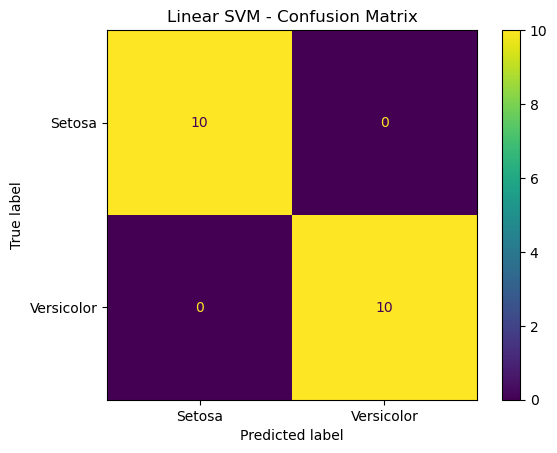

In [13]:
cm_linear = confusion_matrix(y_test, y_pred_linear)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_linear,
    display_labels=["Setosa", "Versicolor"]
)

disp.plot()
plt.title("Linear SVM - Confusion Matrix")
plt.show()

## 13. Visualize the Linear SVM Decision Boundary

The decision boundary of the Linear SVM is visualized using the two selected features: petal length and petal width.

The plot shows how the trained SVM separates Setosa and Versicolor.

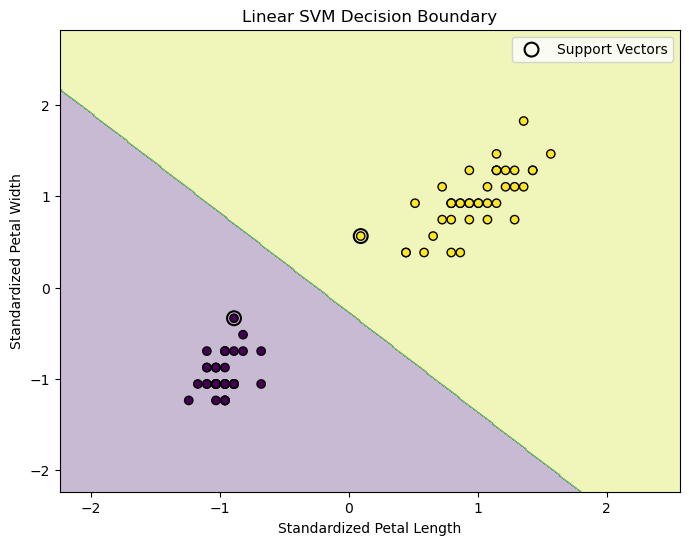

In [14]:
# Create a mesh grid
x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1
y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict classes for every point in the mesh
Z = linear_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot training data
plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolors="k"
)

# Plot support vectors
plt.scatter(
    linear_svm.support_vectors_[:, 0],
    linear_svm.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Support Vectors"
)

plt.xlabel("Standardized Petal Length")
plt.ylabel("Standardized Petal Width")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.show()

## 14. Train an RBF SVM Model

An SVM with the Radial Basis Function (RBF) kernel is trained to capture potentially non-linear relationships between the features.

The RBF kernel is compared with the Linear SVM to determine whether a non-linear decision boundary provides any performance improvement.

In [15]:
# Create the RBF SVM model
rbf_svm = SVC(kernel="rbf", probability=True, random_state=42)

# Train the model
rbf_svm.fit(X_train_scaled, y_train)

print("RBF SVM model trained successfully.")

RBF SVM model trained successfully.


## 15. Evaluate the RBF SVM Model

The RBF SVM is evaluated using accuracy, precision, recall, and AUC.

In [16]:
# Make predictions
y_pred_rbf = rbf_svm.predict(X_test_scaled)

# Predict probabilities for AUC
y_prob_rbf = rbf_svm.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
precision_rbf = precision_score(y_test, y_pred_rbf)
recall_rbf = recall_score(y_test, y_pred_rbf)
auc_rbf = roc_auc_score(y_test, y_prob_rbf)

print("RBF SVM Performance")
print("-------------------")
print(f"Accuracy : {accuracy_rbf:.4f}")
print(f"Precision: {precision_rbf:.4f}")
print(f"Recall   : {recall_rbf:.4f}")
print(f"AUC      : {auc_rbf:.4f}")

RBF SVM Performance
-------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
AUC      : 1.0000


## 16. RBF SVM Classification Report

In [17]:
print(classification_report(
    y_test,
    y_pred_rbf,
    target_names=["Setosa", "Versicolor"]
))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## 17. RBF SVM Confusion Matrix

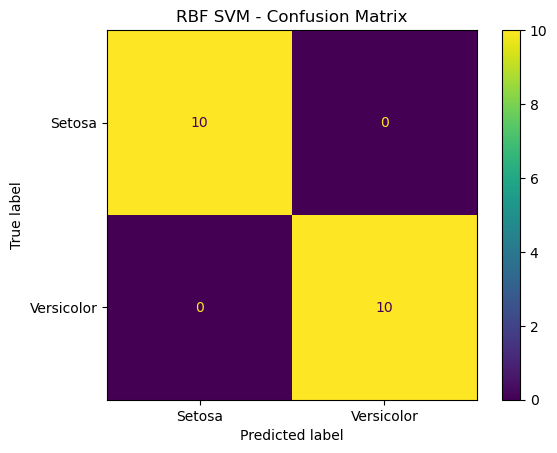

In [18]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rbf,
    display_labels=["Setosa", "Versicolor"]
)

disp.plot()
plt.title("RBF SVM - Confusion Matrix")
plt.show()

## 18. Visualize the RBF SVM Decision Boundary

The decision boundary of the RBF SVM is visualized to observe how the non-linear kernel separates Setosa and Versicolor.

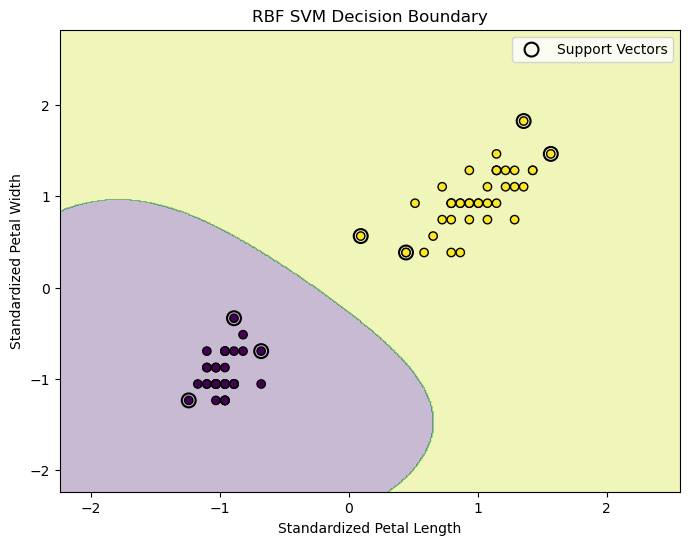

In [19]:
# Create a mesh grid
x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1
y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict classes for every point in the mesh
Z = rbf_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot training data
plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolors="k"
)

# Plot support vectors
plt.scatter(
    rbf_svm.support_vectors_[:, 0],
    rbf_svm.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Support Vectors"
)

plt.xlabel("Standardized Petal Length")
plt.ylabel("Standardized Petal Width")
plt.title("RBF SVM Decision Boundary")
plt.legend()
plt.show()

## 19. Compare Linear and RBF SVM Models

The performance of the Linear and RBF SVM models is compared using accuracy, precision, recall, and AUC.

In [20]:
# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    "Model": ["Linear SVM", "RBF SVM"],
    "Kernel": ["Linear", "RBF"],
    "Accuracy": [accuracy_linear, accuracy_rbf],
    "Precision": [precision_linear, precision_rbf],
    "Recall": [recall_linear, recall_rbf],
    "AUC": [auc_linear, auc_rbf]
})

comparison_df

,Model,Kernel,Accuracy,Precision,Recall,AUC
0,Linear SVM,Linear,1.0,1.0,1.0,1.0
1,RBF SVM,RBF,1.0,1.0,1.0,1.0


## 20. Performance Comparison

The performance of both SVM kernels is visualized to make the comparison easier to interpret.

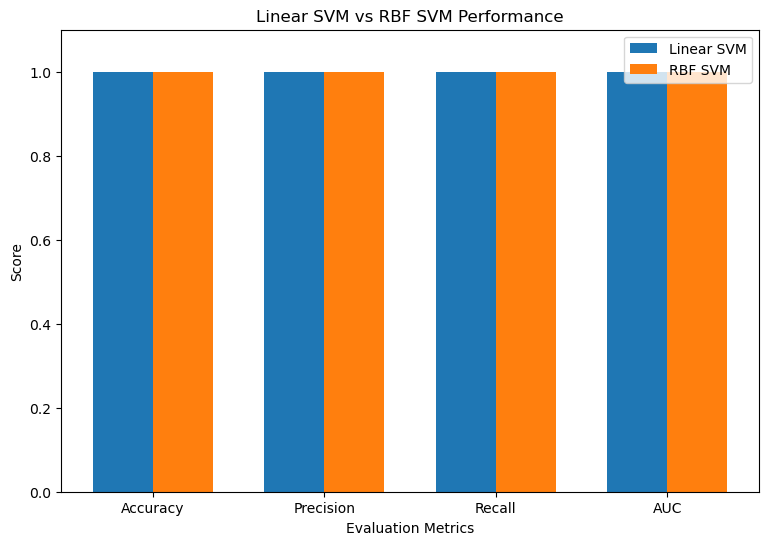

In [21]:
# Plot model performance
metrics = ["Accuracy", "Precision", "Recall", "AUC"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    x - width / 2,
    comparison_df.loc[0, metrics],
    width,
    label="Linear SVM"
)

plt.bar(
    x + width / 2,
    comparison_df.loc[1, metrics],
    width,
    label="RBF SVM"
)

plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")
plt.title("Linear SVM vs RBF SVM Performance")
plt.legend()
plt.show()

## 21. Results and Findings

### Model Performance

Both the Linear SVM and RBF SVM achieved perfect performance on the test dataset:

- Accuracy: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- AUC: 1.0000

### Kernel Comparison

The Linear SVM produced a straight decision boundary, while the RBF SVM produced a non-linear curved decision boundary.

Despite the difference in decision boundaries, both models achieved the same performance on the test set. This indicates that Setosa and Versicolor are highly separable using petal length and petal width.



## 22. ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curve is used to compare the classification performance of the Linear and RBF SVM models across different classification thresholds.

The Area Under the Curve (AUC) summarizes the overall ability of each model to distinguish between Setosa and Versicolor.

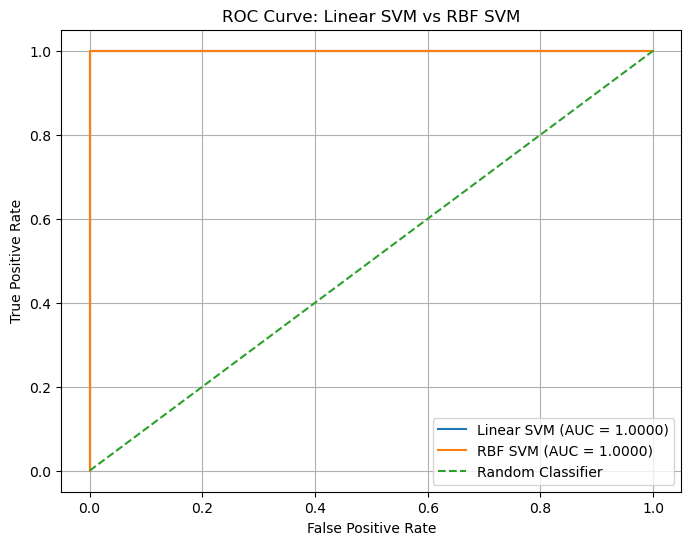

In [22]:
from sklearn.metrics import roc_curve

# Calculate ROC curves
fpr_linear, tpr_linear, _ = roc_curve(y_test, y_prob_linear)
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, y_prob_rbf)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_linear,
    tpr_linear,
    label=f"Linear SVM (AUC = {auc_linear:.4f})"
)

plt.plot(
    fpr_rbf,
    tpr_rbf,
    label=f"RBF SVM (AUC = {auc_rbf:.4f})"
)

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Linear SVM vs RBF SVM")
plt.legend()
plt.grid(True)
plt.show()

## 23. Final Conclusion

The Support Vector Machine models successfully performed binary classification on the Iris dataset.

The original dataset was reduced to two classes, Setosa and Versicolor, and petal length and petal width were selected as features. The features were standardized before training the models.

Two SVM kernels were evaluated:

- Linear Kernel
- RBF Kernel

Both models achieved the following test performance:

| Metric | Linear SVM | RBF SVM |
|---|---:|---:|
| Accuracy | 1.0000 | 1.0000 |
| Precision | 1.0000 | 1.0000 |
| Recall | 1.0000 | 1.0000 |
| AUC | 1.0000 | 1.0000 |

The Linear SVM produced a straight decision boundary, while the RBF SVM produced a curved decision boundary. However, the RBF kernel did not provide any performance improvement because the two classes were already highly separable using the selected features.

Overall, the Linear SVM is the preferred model for this dataset because it achieves the same performance as the RBF SVM while using a simpler decision boundary.